# Notebook 09 : Chaînes TLE — Persistance et diagnostic algorithmique
# TLE Chain Analysis — Persistence and Algorithmic Diagnosis

**Projet :** OJS Submission Analytics — Ritsumeikan University (DDSE Lab)
**Auteur :** Raphael BELY

**CSV utilisé :** `data/processed/atcoder_tle_chains.csv`

**Structure :**
- **S0** : Distribution des longueurs de chaîne TLE (nb de TLEs consécutifs par tentative)
- **S1** : Outcome final de chaîne selon le délai inter-TLE — vue globale + zoom niveau D par groupe
- **S3** : Outcome final selon la longueur totale de la chaîne
- **S4** : Dernière transition avant sortie de chaîne — intra-session (≤4h) vs inter-session (>4h)
- **S5** : Délai médian entre TLEs selon la position dans la chaîne (accélération)
- **S6** : Outcome final selon le temps total passé dans la chaîne (somme des délais inter-TLE)
- **S7** : Outcome final selon le délai inter-TLE **moyen** de la chaîne (biais S1 corrigé — une chaîne = un point)

---

**CSV used:** `data/processed/atcoder_tle_chains.csv`

**Structure:**
- **S0**: Distribution of TLE chain lengths (number of consecutive TLEs per attempt)
- **S1**: Final chain outcome by inter-TLE delay — global view + zoom on level D by group
- **S3**: Final outcome by total chain length
- **S4**: Last transition before chain exit — intra-session (≤4h) vs inter-session (>4h)
- **S5**: Median inter-TLE delay by position in the chain (acceleration effect)
- **S6**: Final outcome by total time spent in the chain (sum of inter-TLE delays)
- **S7**: Final outcome by **mean** inter-TLE delay per chain (S1 bias corrected — one chain = one data point)

## Motivation — Pourquoi analyser les chaînes TLE ?
## Motivation — Why Analyze TLE Chains?

Le NB08 montre une corrélation positive entre le délai après un TLE et le taux d'AC (intra-session). Cette corrélation ne peut pas s'interpréter causalement : les utilisateurs qui comprennent déjà le problème prennent naturellement plus de temps pour implémenter la correction proprement. Le délai est un symptôme de la compréhension, pas sa cause.

Le seul finding discriminant de NB08 est l'anomalie 2–5 min sur D/E/F, qui invalide le mécanisme purement causal — mais son amplitude est faible et elle ne s'étend pas aux niveaux B/C.

**Ce notebook propose un test plus ciblé** : en filtrant aux transitions TLE→TLE (les deux soumissions encadrantes sont des TLE), on s'assure que l'utilisateur est en situation de blocage confirmé. L'hypothèse centrale :

- *Patch aveugle :* re-soumission rapide sans identifier la cause algorithmique → nouveau TLE → longue chaîne
- *Diagnostic algorithmique :* analyse de la complexité avant re-soumission → délai plus long → sortie rapide de la chaîne

Si ce modèle est correct, un délai inter-TLE plus long devrait être associé à un meilleur outcome final de chaîne, et ce de façon plus nette que dans NB08 (où le signal causal se noie dans la sélection naturelle des utilisateurs compétents).

---

NB08 shows a positive correlation between post-TLE delay and AC rate (intra-session). This correlation cannot be interpreted causally: users who already understand the problem naturally take more time to implement the fix properly. The delay is a symptom of understanding, not its cause.

The only discriminating finding from NB08 is the 2–5 min anomaly on D/E/F, which rules out a purely causal mechanism — but its magnitude is small and it does not extend to levels B/C.

**This notebook proposes a more targeted test**: by filtering to TLE→TLE transitions (both bounding submissions are TLEs), we ensure the user is in a confirmed deadlock situation. The central hypothesis:

- *Blind patch:* quick resubmission without identifying the algorithmic cause → new TLE → long chain
- *Algorithmic diagnosis:* complexity analysis before resubmission → longer delay → quick chain exit

If this model holds, a longer inter-TLE delay should be associated with a better final chain outcome, more clearly than in NB08 (where the causal signal is diluted by the natural selection of competent users).

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

DATA_DIR = Path('../data/processed')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

STATUS_COLORS = {
    'AC':      '#2ecc71',
    'WA':      '#e74c3c',
    'TLE':     '#f39c12',
    'CE':      '#3498db',
    'RE':      '#9b59b6',
    'Other':   '#7f8c8d',
    'Abandon': '#bdc3c7',
}

S1_EDGES  = [0, 2, 5, 15, 30, 60, 120, float('inf')]
S1_LABELS = ['0–2 min', '2–5 min', '5–15 min', '15–30 min', '30–60 min', '1–2h', '>2h']
OUTCOMES_CHAIN = ['AC', 'WA', 'RE', 'CE', 'Abandon', 'Other']


def plot_delay_outcome(df_input, title, ax):
    # Barres empilees : bin de delai inter-TLE -> distribution des outcomes finaux de chaine
    bin_counts = {}
    bin_totals = {}
    for j, label in enumerate(S1_LABELS):
        lo, hi = S1_EDGES[j], S1_EDGES[j + 1]
        sub = df_input.filter((pl.col('delta_min') >= lo) & (pl.col('delta_min') < hi))
        n = sub.height
        bin_totals[label] = max(n, 1)
        bin_counts[label] = {s: sub.filter(pl.col('chain_final_outcome') == s).height
                              for s in OUTCOMES_CHAIN}

    bottoms = np.zeros(len(S1_LABELS))
    for outcome in OUTCOMES_CHAIN:
        pcts = np.array([
            100 * bin_counts[l][outcome] / bin_totals[l]
            for l in S1_LABELS
        ])
        ax.bar(S1_LABELS, pcts, bottom=bottoms,
               color=STATUS_COLORS.get(outcome, '#888'), label=outcome, width=0.7)
        for i, (pct, bot) in enumerate(zip(pcts, bottoms)):
            if pct > 4:
                ax.text(i, bot + pct / 2, f'{pct:.0f}%',
                        ha='center', va='center', fontsize=7,
                        fontweight='bold', color='white')
        bottoms += pcts

    for i, label in enumerate(S1_LABELS):
        n = bin_totals[label]
        if n > 1:
            clr = '#c0392b' if n < 150 else '#333'
            ax.text(i, -5, f'n={n:,}', ha='center', va='top', fontsize=8,
                    fontweight='bold', color=clr)

    ax.set_ylim(-14, 108)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('% des transitions TLE→TLE', fontsize=8)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.2)

In [2]:
df_chains = (
    pl.read_csv(DATA_DIR / 'atcoder_tle_chains.csv')
    .with_columns(pl.col('chain_final_outcome').fill_null('Abandon'))
)

df_intra  = df_chains.filter(pl.col('is_intra_session'))
df_unique = df_intra.filter(pl.col('chain_position') == 1)

print(f'Transitions TLE→TLE totales  : {df_chains.height:,}')
print(f'  Intra-session (≤4h)         : {df_intra.height:,}  ({100*df_intra.height/df_chains.height:.1f}%)')
print(f'  Inter-session (>4h)          : {df_chains.height - df_intra.height:,}')
print(f'Chaînes uniques (intra)        : {df_unique.height:,}')
print()
print('Outcomes finaux de chaîne (intra, dédupliqué) :')
print(
    df_unique.group_by('chain_final_outcome').agg(pl.len().alias('n'))
    .sort('n', descending=True)
)

Transitions TLE→TLE totales  : 185,840
  Intra-session (≤4h)         : 175,674  (94.5%)
  Inter-session (>4h)          : 10,166
Chaînes uniques (intra)        : 99,502

Outcomes finaux de chaîne (intra, dédupliqué) :
shape: (6, 2)
┌─────────────────────┬───────┐
│ chain_final_outcome ┆ n     │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ AC                  ┆ 41089 │
│ WA                  ┆ 25481 │
│ Abandon             ┆ 20598 │
│ RE                  ┆ 9511  │
│ CE                  ┆ 2756  │
│ Other               ┆ 67    │
└─────────────────────┴───────┘


---
## Section 0 — Distribution des longueurs de chaîne TLE
## TLE Chain Length Distribution

Une **chaîne TLE** = séquence consécutive de TLEs par un même utilisateur sur un même problème, séparés par ≤4h (intra-session).
La longueur de chaîne = nombre total de TLEs avant la sortie (AC, WA, abandon…).

La longueur 1 signifie un TLE isolé (pas de chaîne) ; les chaînes présentes dans ce CSV ont longueur ≥2.

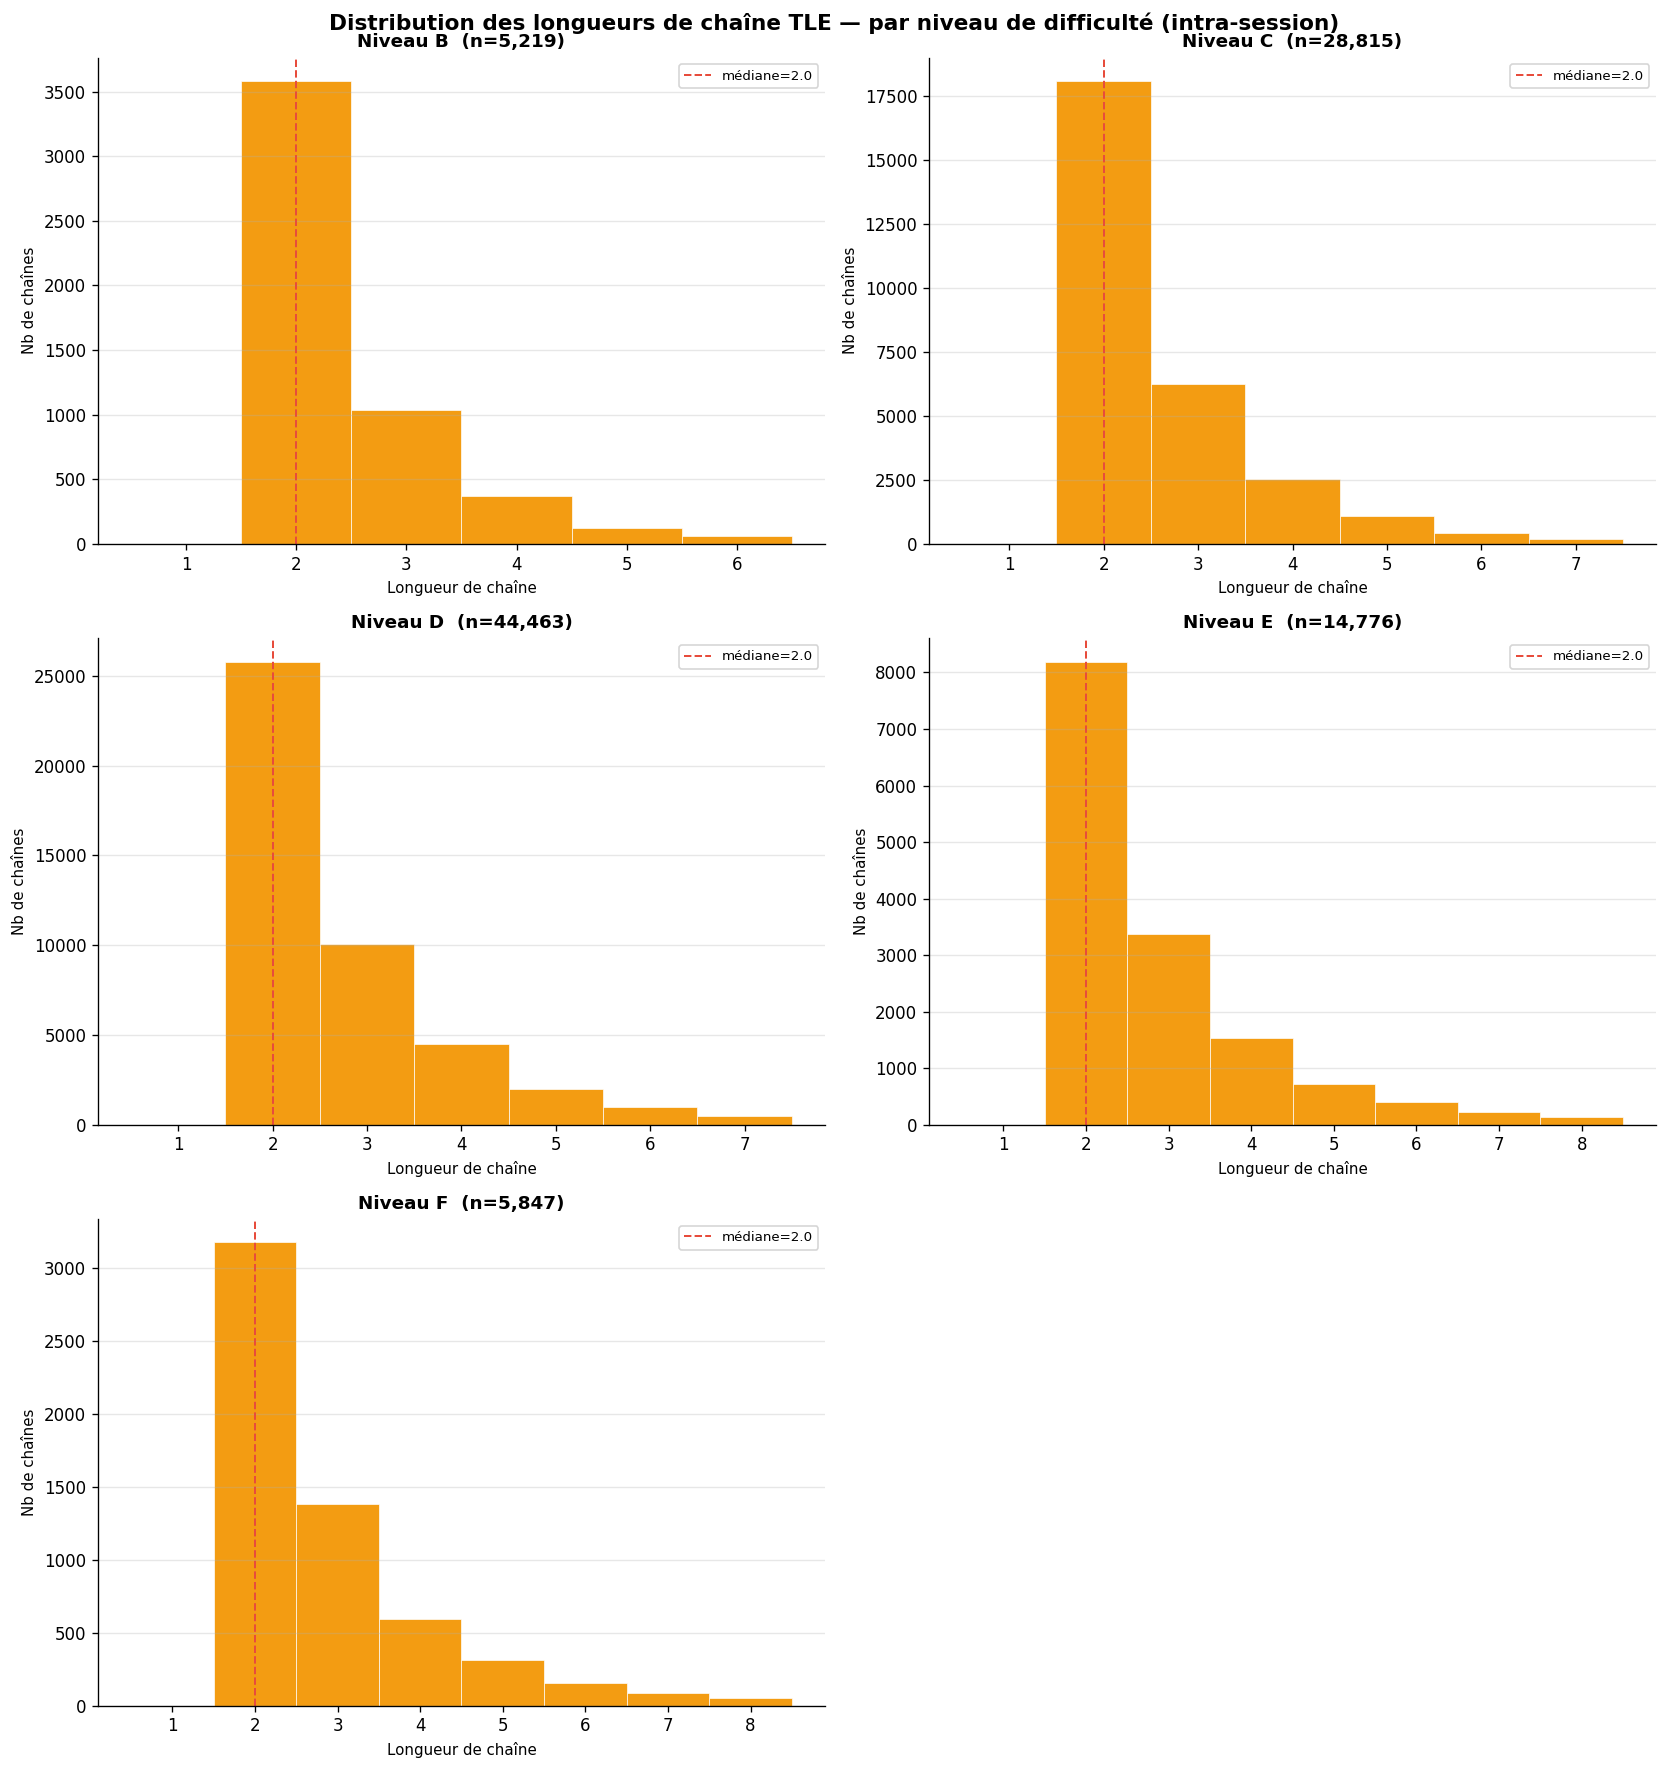

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharey=False)
axes = axes.flatten()

for ax, diff in zip(axes, ['B', 'C', 'D', 'E', 'F']):
    sub = df_unique.filter(pl.col('difficulty') == diff)['chain_length'].to_numpy()
    n = len(sub)
    if n < 10:
        ax.text(0.5, 0.5, f'Niveau {diff}\nn={n}', ha='center', va='center', transform=ax.transAxes)
        continue
    max_len = min(int(np.percentile(sub, 95)) + 2, 20)
    bins = np.arange(0.5, max_len + 1.5)
    ax.hist(sub, bins=bins, color='#f39c12', edgecolor='white', linewidth=0.4)
    ax.set_title(f'Niveau {diff}  (n={n:,})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Longueur de chaîne', fontsize=9)
    ax.set_ylabel('Nb de chaînes', fontsize=9)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3)
    median_len = float(np.median(sub))
    ax.axvline(median_len, color='#e74c3c', linestyle='--', linewidth=1.2,
               label=f'médiane={median_len:.1f}')
    ax.legend(fontsize=8)

axes[5].set_visible(False)

fig.suptitle(
    'Distribution des longueurs de chaîne TLE — par niveau de difficulté (intra-session)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 1 — Outcome final de chaîne selon le délai inter-TLE
## Final Chain Outcome by Inter-TLE Delay

Pour chaque transition TLE→TLE, on regarde le délai avant la re-soumission (en minutes) et l'outcome **final** de la chaîne (AC, WA, Abandon…).

Contrairement à NB08 (délai TLE→next, toutes transitions), ici les deux bornes sont garanties TLE : l'utilisateur est en blocage confirmé. Le signal est donc plus propre.

**Résultat attendu si le modèle "diagnostic algorithmique" est correct :** un délai plus long → AC final plus fréquent, de façon plus nette qu'en NB08 où la sélection naturelle brouille le signal.

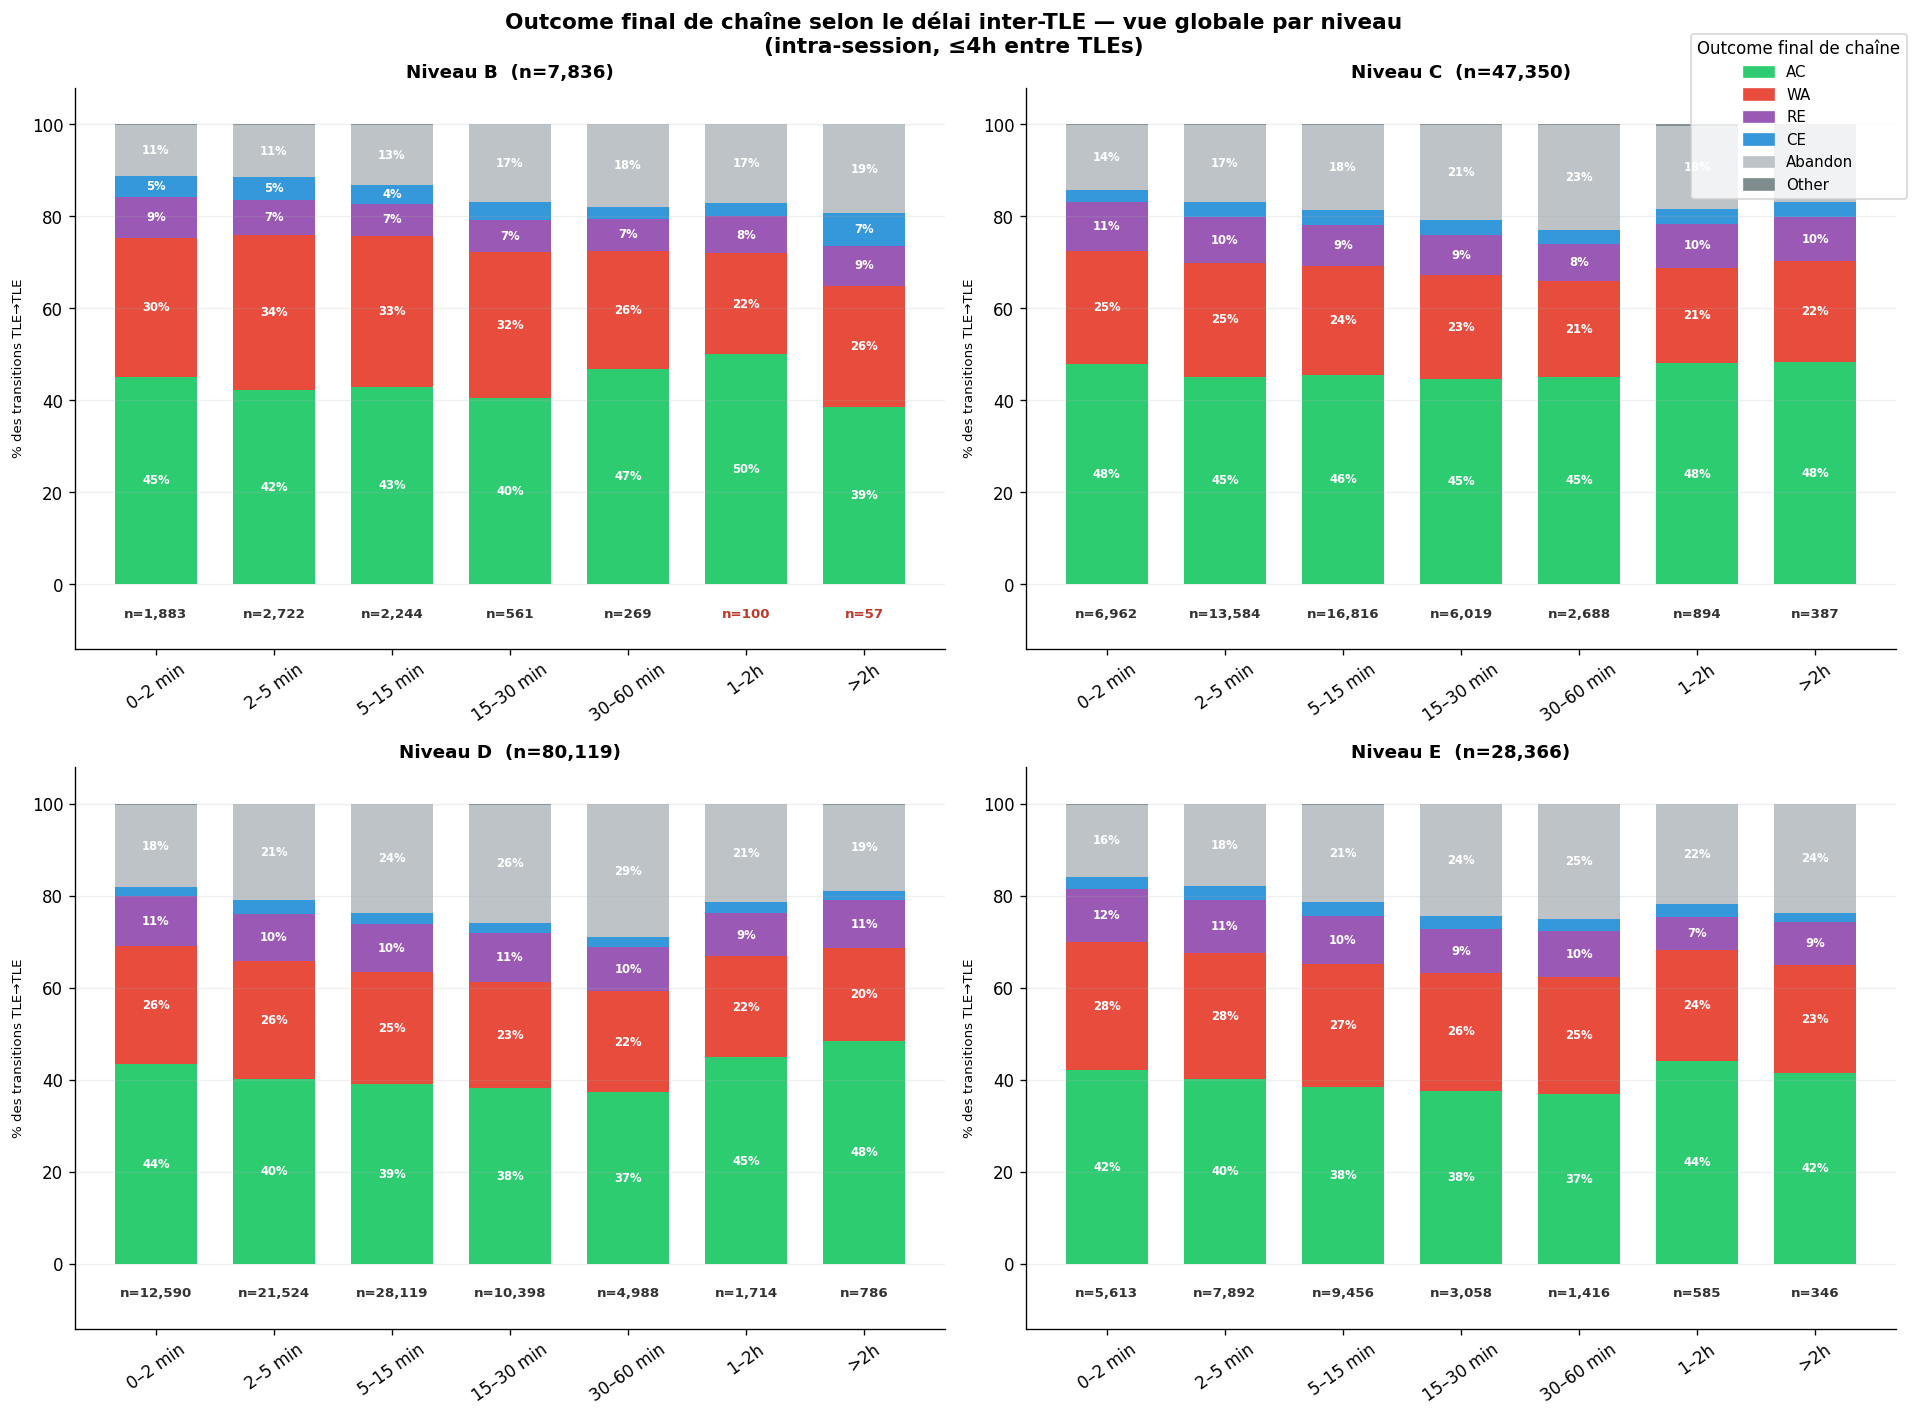

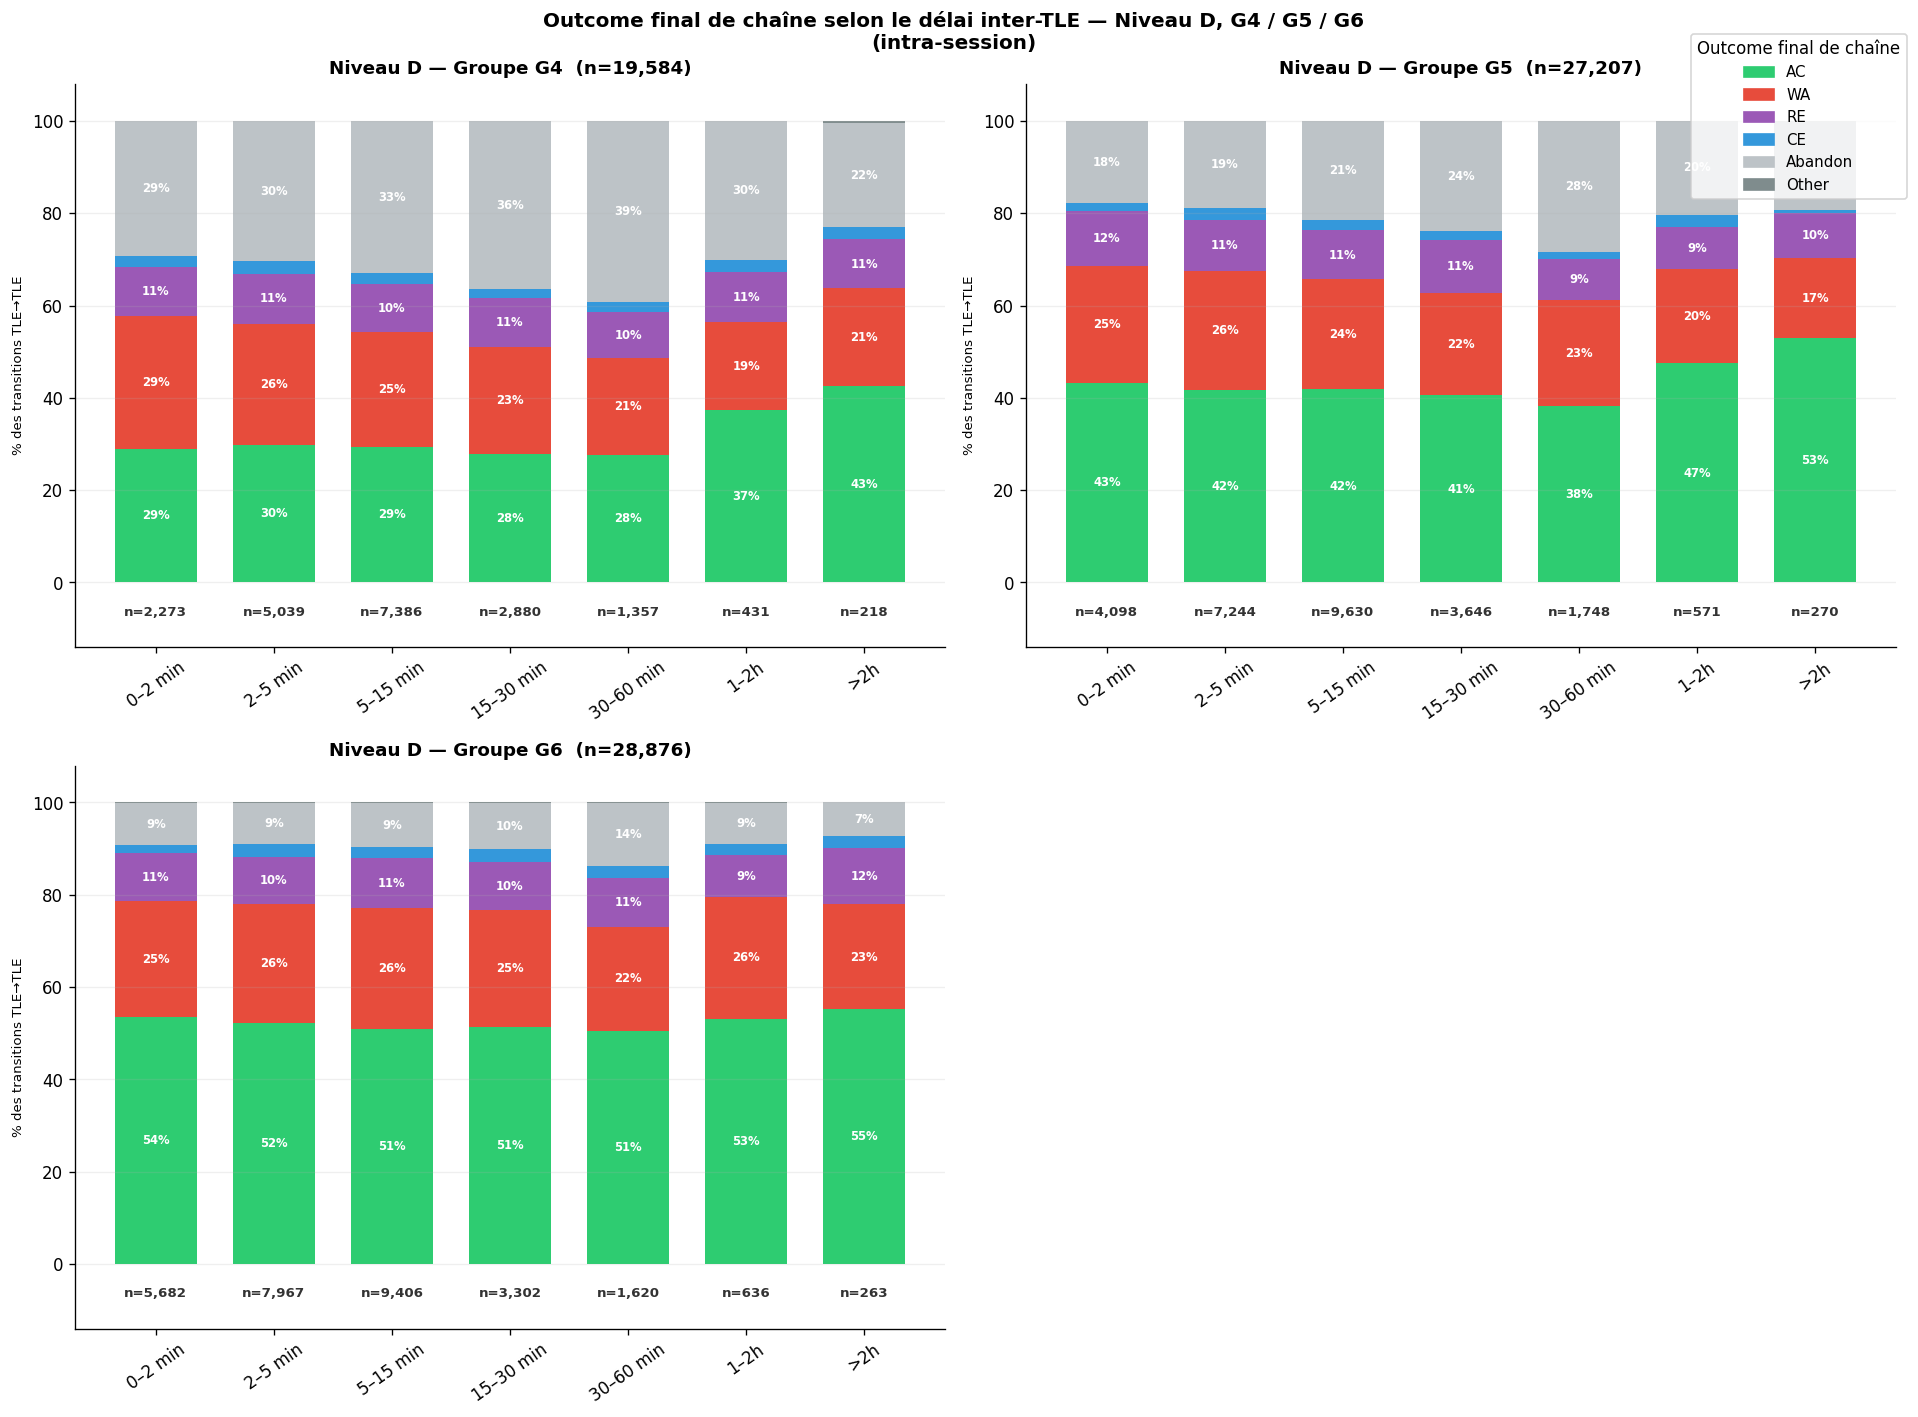

In [4]:
df_s1 = df_intra.with_columns((pl.col('delta_seconds') / 60).alias('delta_min'))

# Figure 1 : vue globale par niveau (B/C/D/E, 2×2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for ax, diff in zip(axes, ['B', 'C', 'D', 'E']):
    sub = df_s1.filter(pl.col('difficulty') == diff)
    plot_delay_outcome(sub, f'Niveau {diff}  (n={sub.height:,})', ax)

handles = [mpatches.Patch(color=STATUS_COLORS.get(s, '#888'), label=s) for s in OUTCOMES_CHAIN]
fig.legend(handles=handles, title='Outcome final de chaîne', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Outcome final de chaîne selon le délai inter-TLE — vue globale par niveau\n'
    '(intra-session, ≤4h entre TLEs)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Figure 2 : niveau D par groupe (G4/G5/G6, 2×2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for ax, grp in zip(axes, ['G4', 'G5', 'G6']):
    sub = df_s1.filter((pl.col('difficulty') == 'D') & (pl.col('proficiency_group') == grp))
    plot_delay_outcome(sub, f'Niveau D — Groupe {grp}  (n={sub.height:,})', ax)

axes[3].set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS.get(s, '#888'), label=s) for s in OUTCOMES_CHAIN]
fig.legend(handles=handles, title='Outcome final de chaîne', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Outcome final de chaîne selon le délai inter-TLE — Niveau D, G4 / G5 / G6\n'
    '(intra-session)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 3 — Outcome final selon la longueur totale de la chaîne
## Final Outcome by Total Chain Length

La longueur de chaîne (nombre total de TLEs dans la séquence) est-elle prédictive de l'outcome final ?
Une chaîne longue = l'utilisateur peine à trouver la solution algorithmique.
Testé sur les niveaux C, D, E (effectifs suffisants pour plusieurs longueurs).

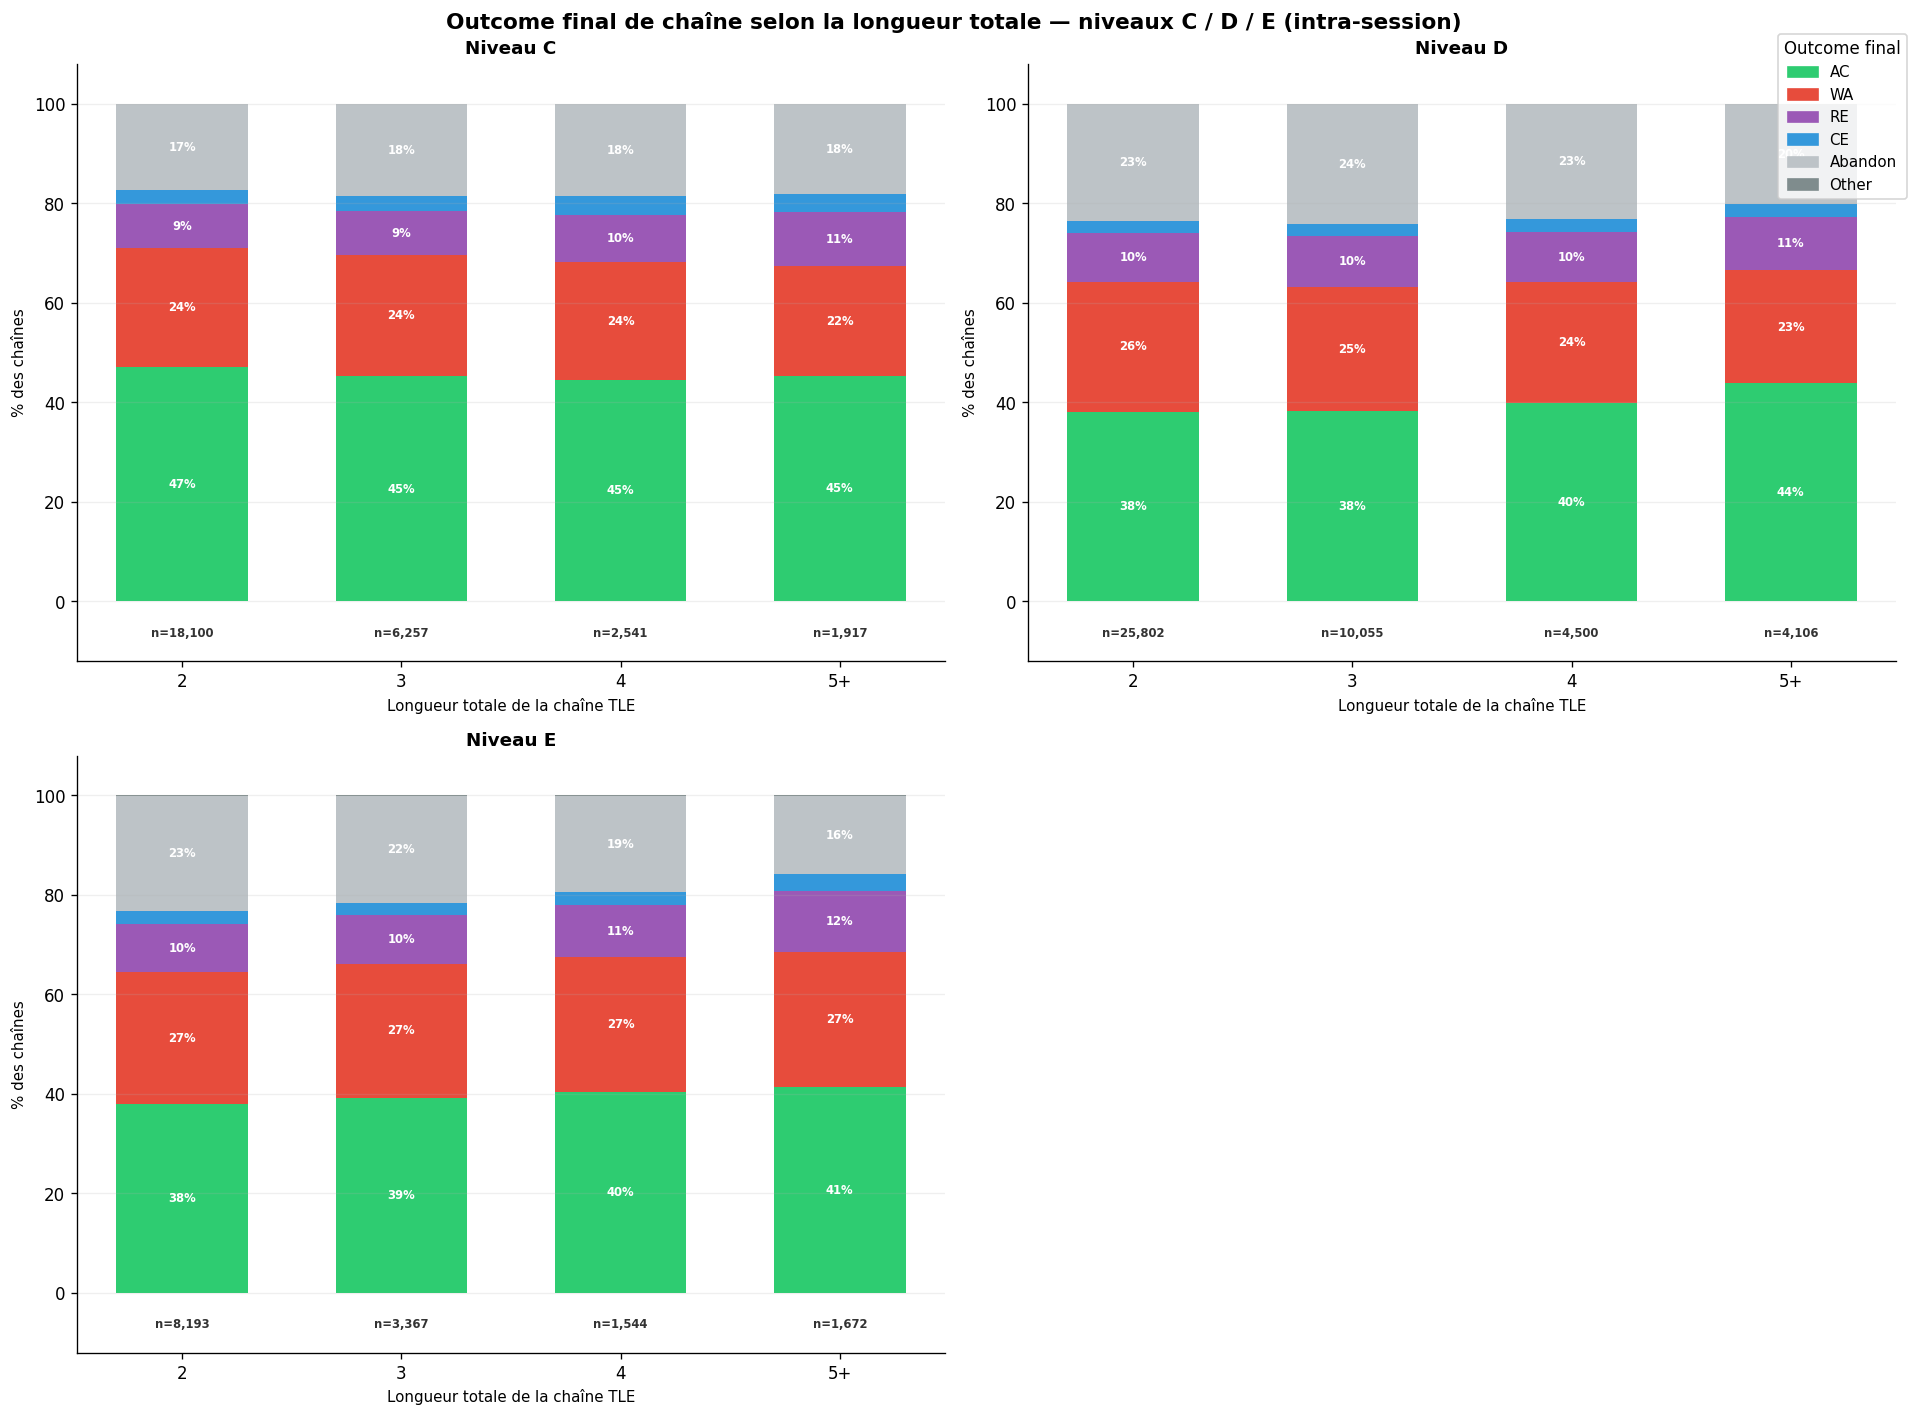

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, diff in zip(axes, ['C', 'D', 'E']):
    sub = df_unique.filter(pl.col('difficulty') == diff).with_columns(
        pl.when(pl.col('chain_length') >= 5)
          .then(pl.lit('5+'))
          .otherwise(pl.col('chain_length').cast(pl.Utf8))
          .alias('len_label')
    )
    labels = ['2', '3', '4', '5+']

    bottoms = np.zeros(len(labels))
    for outcome in OUTCOMES_CHAIN:
        pcts = []
        for lbl in labels:
            grp = sub.filter(pl.col('len_label') == lbl)
            n = grp.height
            pcts.append(100 * grp.filter(pl.col('chain_final_outcome') == outcome).height / max(n, 1))
        pcts = np.array(pcts)
        ax.bar(labels, pcts, bottom=bottoms,
               color=STATUS_COLORS.get(outcome, '#888'), label=outcome, width=0.6)
        for i, (pct, bot) in enumerate(zip(pcts, bottoms)):
            if pct > 6:
                ax.text(i, bot + pct / 2, f'{pct:.0f}%',
                        ha='center', va='center', fontsize=7,
                        fontweight='bold', color='white')
        bottoms += pcts

    for i, lbl in enumerate(labels):
        n = sub.filter(pl.col('len_label') == lbl).height
        clr = '#c0392b' if n < 150 else '#333'
        ax.text(i, -5, f'n={n:,}', ha='center', va='top', fontsize=7,
                fontweight='bold', color=clr)

    ax.set_ylim(-12, 108)
    ax.set_title(f'Niveau {diff}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Longueur totale de la chaîne TLE', fontsize=9)
    ax.set_ylabel('% des chaînes', fontsize=9)
    ax.grid(axis='y', alpha=0.2)

axes[3].set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS.get(s, '#888'), label=s) for s in OUTCOMES_CHAIN]
fig.legend(handles=handles, title='Outcome final', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Outcome final de chaîne selon la longueur totale — niveaux C / D / E (intra-session)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 4 — Dernière transition avant sortie de chaîne
## Last Transition Before Chain Exit

Parmi toutes les transitions TLE→TLE d'une chaîne, la plus pertinente causalement est la **dernière** : celle qui précède immédiatement la sortie (AC, WA, Abandon…). C'est le seul délai pour lequel on peut raisonnablement dire qu'il a précédé et potentiellement influencé la décision algorithmique finale.

Filtre : `chain_position == chain_length - 1` → **une seule ligne par chaîne**.

Comparaison : dernière transition intra-session (≤4h) vs inter-session (>4h).

**Hypothèse :** un long délai sur la dernière transition — signe d'une vraie pause de réflexion juste avant la sortie — devrait être associé à un meilleur outcome final.

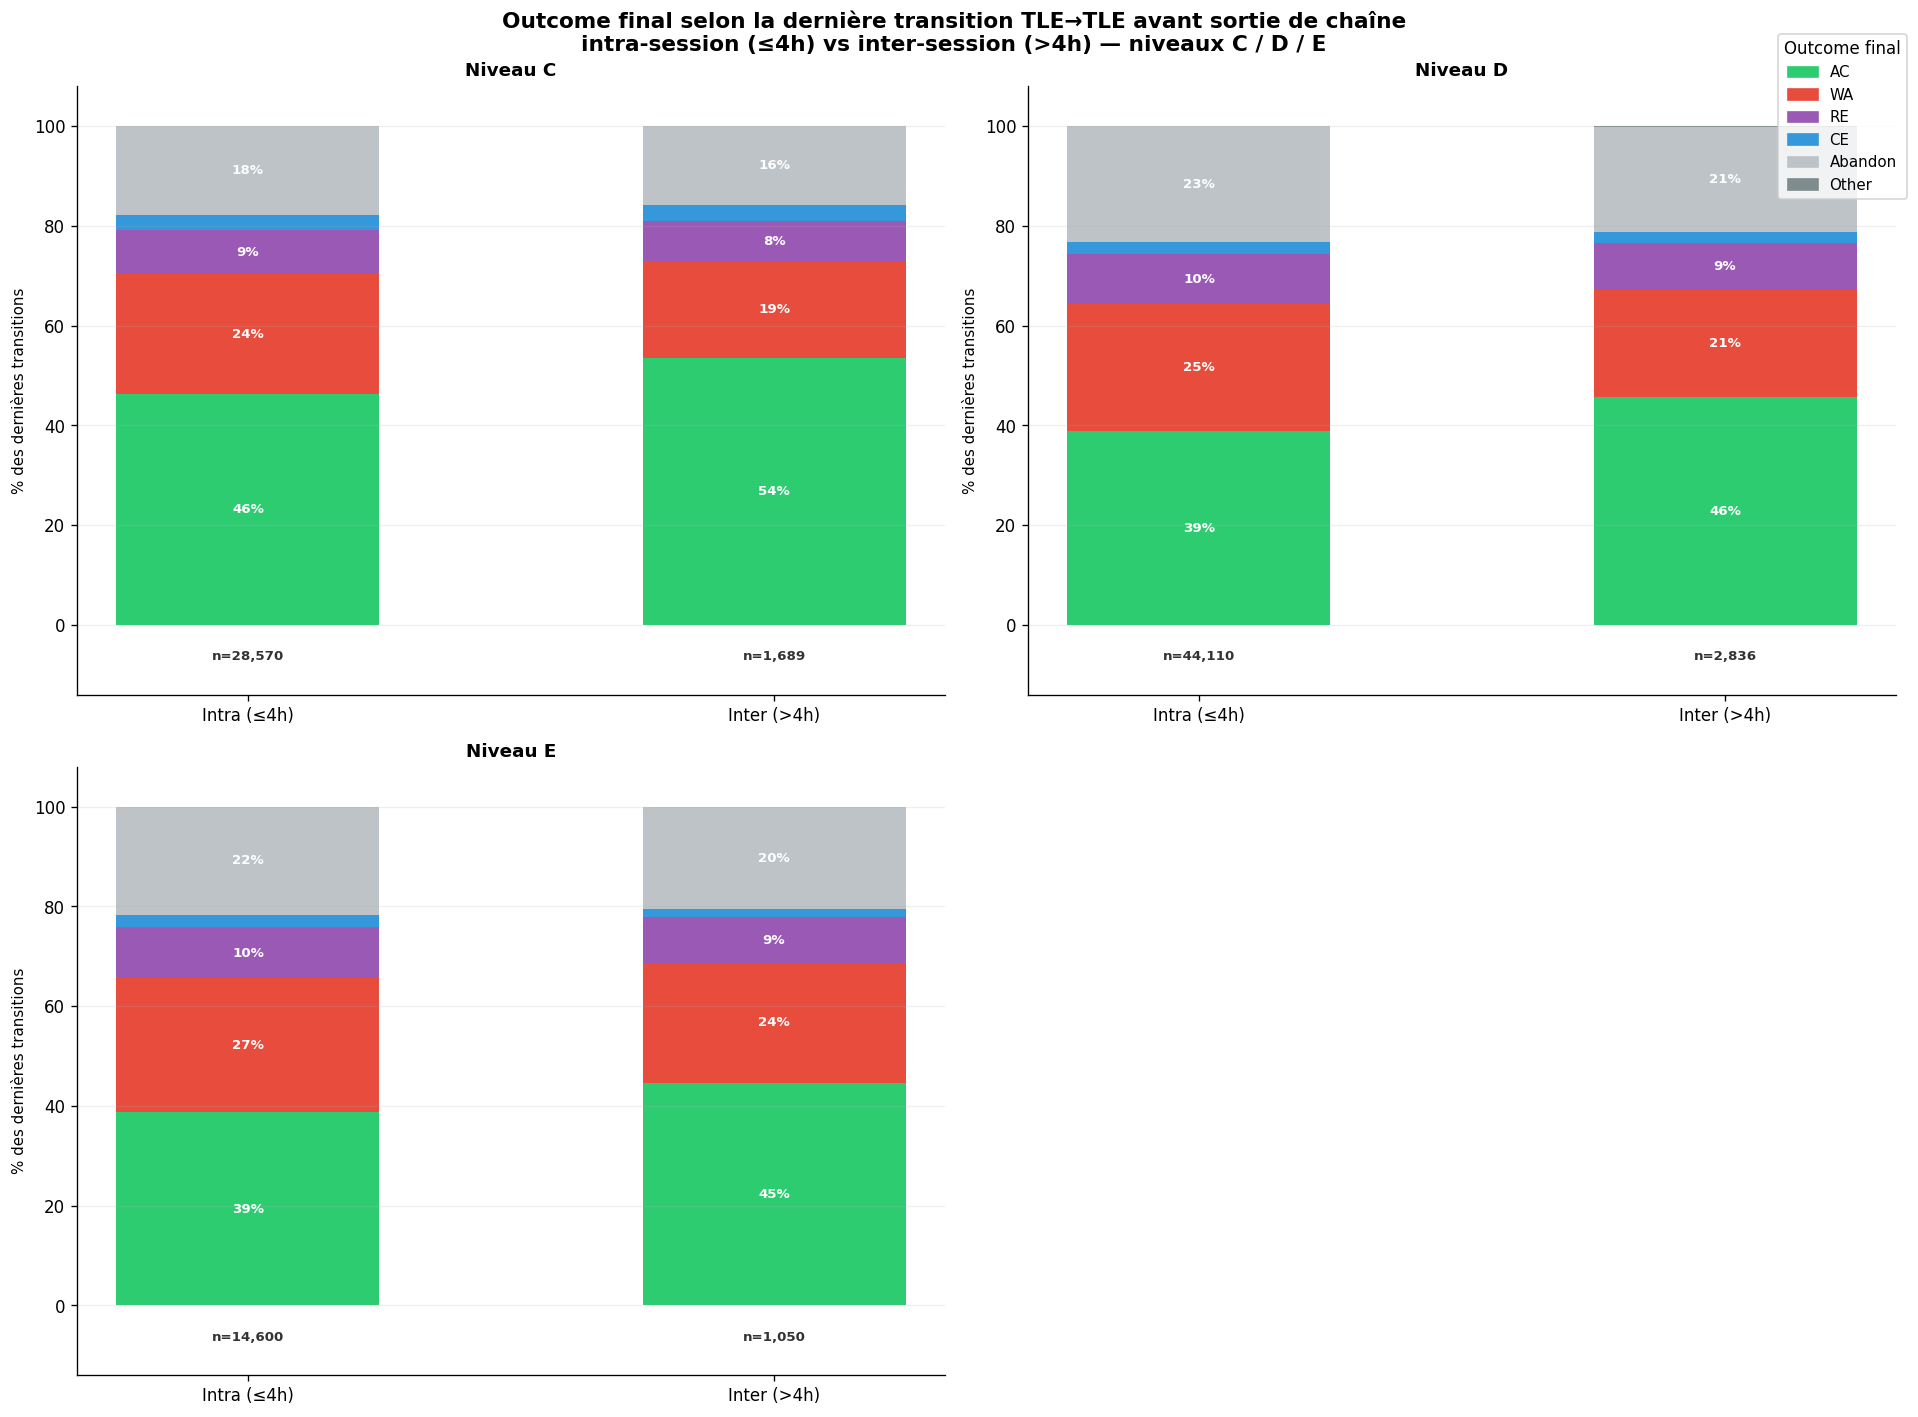

In [6]:
df_last = df_chains.filter(pl.col('chain_position') == pl.col('chain_length') - 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, diff in zip(axes, ['C', 'D', 'E']):
    sub = df_last.filter(pl.col('difficulty') == diff)

    session_data = {
        'Intra (≤4h)': sub.filter(pl.col('is_intra_session')),
        'Inter (>4h)':  sub.filter(~pl.col('is_intra_session')),
    }
    x_labels = list(session_data.keys())

    bottoms = np.zeros(len(x_labels))
    for outcome in OUTCOMES_CHAIN:
        pcts = []
        for label in x_labels:
            grp = session_data[label]
            n = grp.height
            pcts.append(100 * grp.filter(pl.col('chain_final_outcome') == outcome).height / max(n, 1))
        pcts = np.array(pcts)
        ax.bar(x_labels, pcts, bottom=bottoms,
               color=STATUS_COLORS.get(outcome, '#888'), label=outcome, width=0.5)
        for i, (pct, bot) in enumerate(zip(pcts, bottoms)):
            if pct > 6:
                ax.text(i, bot + pct / 2, f'{pct:.0f}%',
                        ha='center', va='center', fontsize=8,
                        fontweight='bold', color='white')
        bottoms += pcts

    for i, label in enumerate(x_labels):
        n = session_data[label].height
        clr = '#c0392b' if n < 150 else '#333'
        ax.text(i, -5, f'n={n:,}', ha='center', va='top', fontsize=8,
                fontweight='bold', color=clr)

    ax.set_ylim(-14, 108)
    ax.set_title(f'Niveau {diff}', fontsize=11, fontweight='bold')
    ax.set_ylabel('% des dernières transitions', fontsize=9)
    ax.grid(axis='y', alpha=0.2)

axes[3].set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS.get(s, '#888'), label=s) for s in OUTCOMES_CHAIN]
fig.legend(handles=handles, title='Outcome final', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Outcome final selon la dernière transition TLE→TLE avant sortie de chaîne\n'
    'intra-session (≤4h) vs inter-session (>4h) — niveaux C / D / E',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 5 — Accélération des re-soumissions au fil de la chaîne
## Re-submission Acceleration Along the TLE Chain

Les utilisateurs soumettent-ils plus vite à mesure que la chaîne s'allonge ?

**Hypothèse :** une chaîne longue induit de la frustration → les intervalles inter-TLE raccourcissent progressivement (patch aveugle qui s'emballe). À l'inverse, une décélération suggérerait une réflexion croissante.

Visualisation agrégée (tous groupes) : médiane du délai inter-TLE par position dans la chaîne, avec bande IQR (P25–P75) pour quantifier la dispersion individuelle.

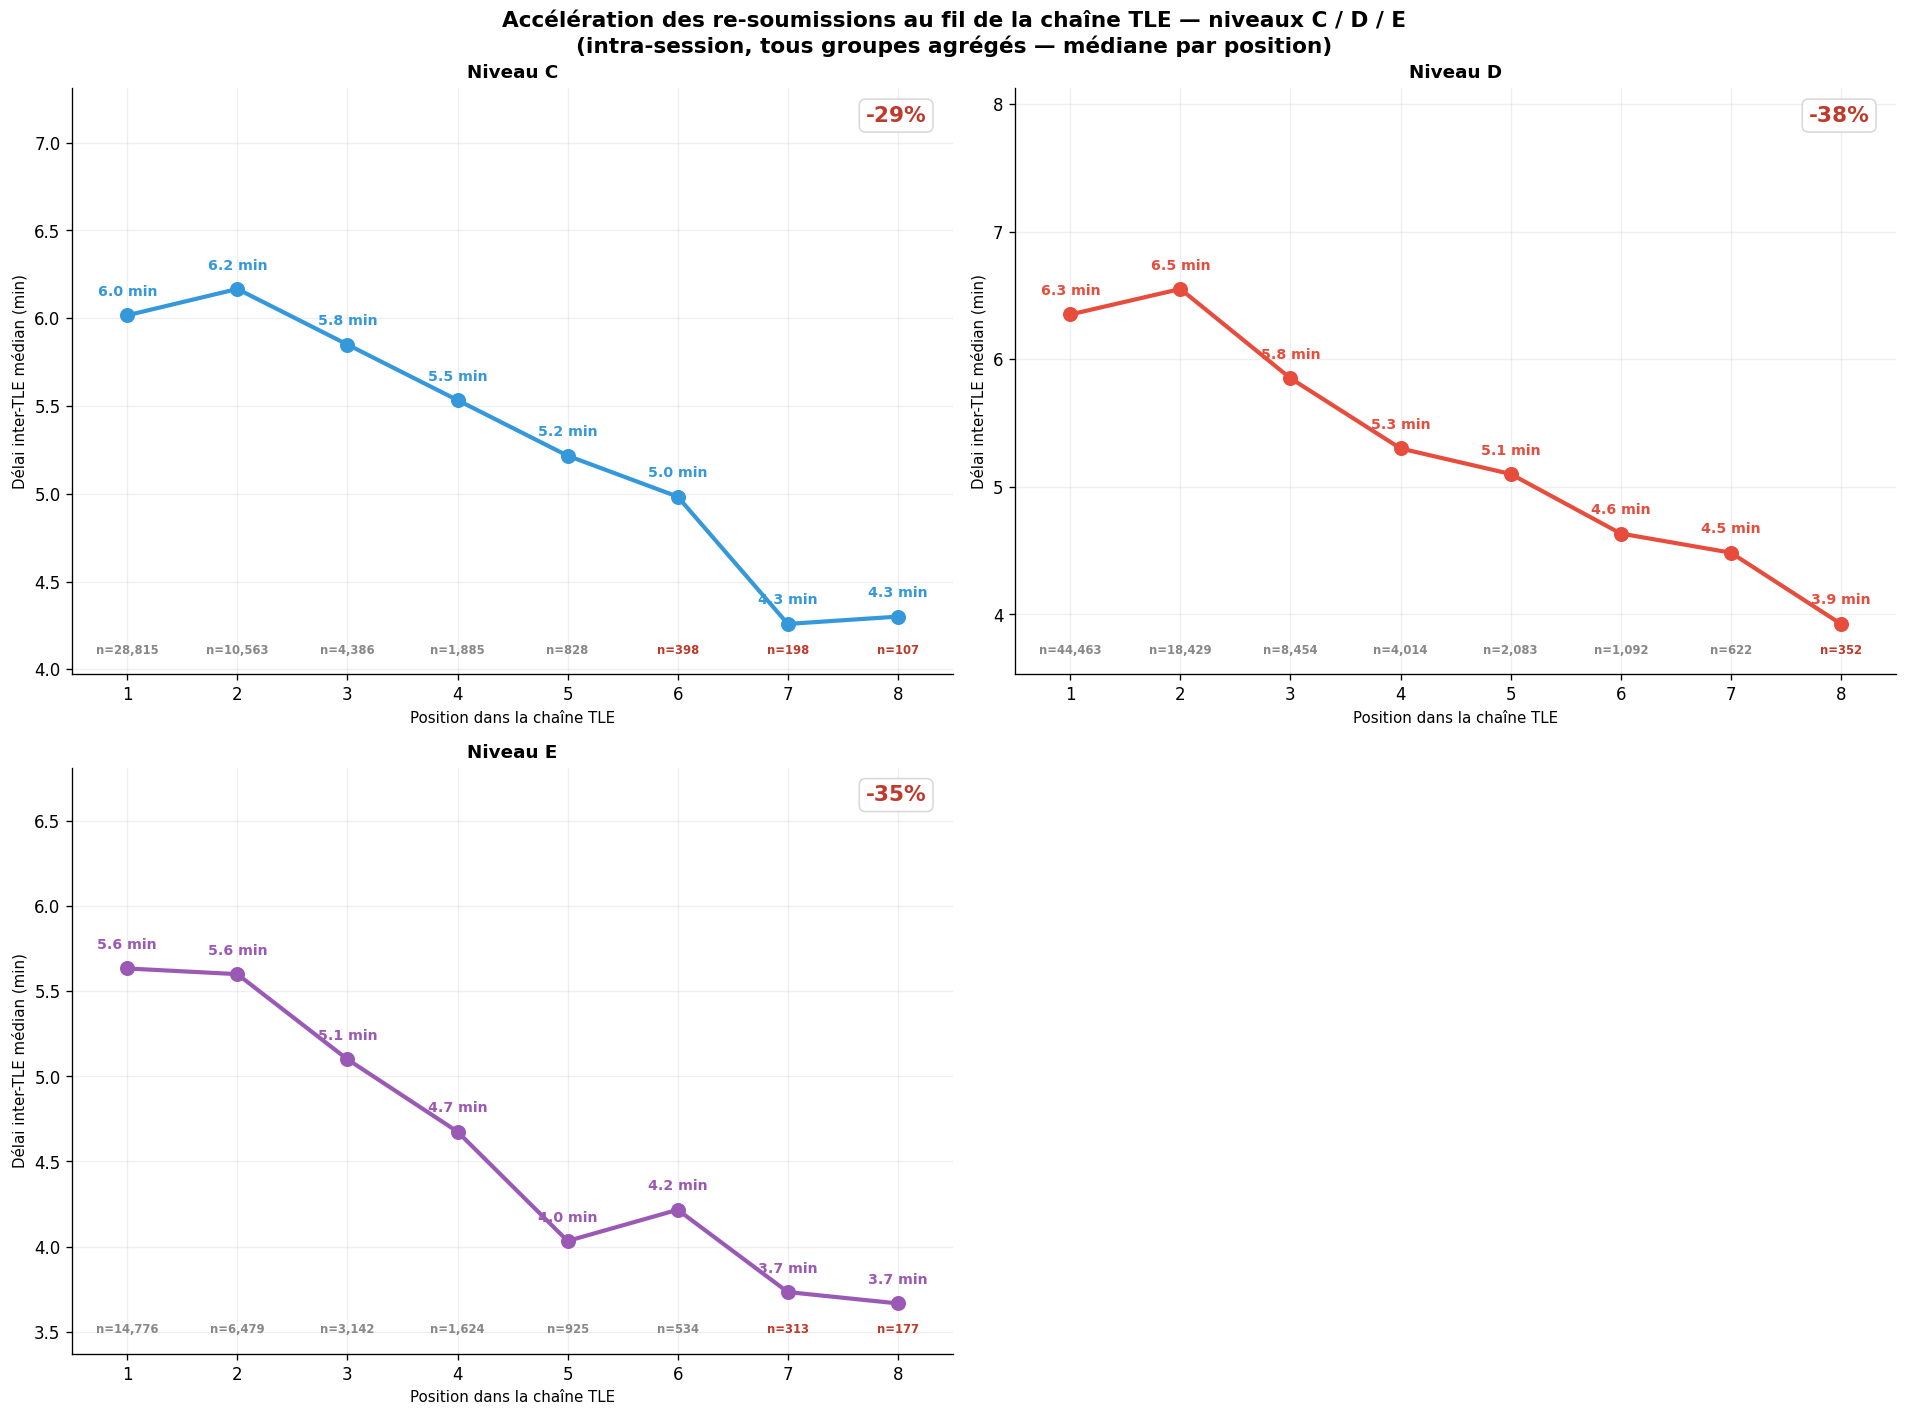

In [7]:
COLORS_DIFF = {'C': '#3498db', 'D': '#e74c3c', 'E': '#9b59b6'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (ax, diff) in enumerate(zip(axes[:3], ['C', 'D', 'E'])):
    sub = df_intra.filter(pl.col('difficulty') == diff)
    max_pos = min(int(sub['chain_position'].max() or 1), 8)

    positions, medians, ns = [], [], []
    for pos in range(1, max_pos + 1):
        d = sub.filter(pl.col('chain_position') == pos)['delta_seconds']
        n = d.len()
        if n >= 30:
            positions.append(pos)
            medians.append(float(d.median()) / 60)
            ns.append(n)

    if len(positions) == 0:
        ax.set_title(f'Niveau {diff} — pas assez de données', fontsize=11)
        continue

    positions = np.array(positions)
    medians   = np.array(medians)
    color = COLORS_DIFF[diff]

    ax.plot(positions, medians, 'o-', color=color, linewidth=2.5, markersize=8, zorder=3)

    for pos, med in zip(positions.tolist(), medians.tolist()):
        ax.annotate(f'{med:.1f} min', (pos, med),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', va='bottom', fontsize=8.5,
                    color=color, fontweight='bold')

    for pos, n in zip(positions.tolist(), ns):
        clr = '#c0392b' if n < 500 else '#888'
        ax.text(pos, 0.03, f'n={n:,}',
                transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=7, color=clr, fontweight='bold')

    if len(medians) >= 2:
        pct = 100 * (medians[-1] - medians[0]) / medians[0]
        ax.text(0.97, 0.97, f'{pct:+.0f}%',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=13, fontweight='bold',
                color='#c0392b' if pct < 0 else '#27ae60',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.85, edgecolor='lightgray'))

    ax.set_title(f'Niveau {diff}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Position dans la chaîne TLE', fontsize=9)
    ax.set_ylabel('Délai inter-TLE médian (min)', fontsize=9)
    ax.set_xlim(0.5, max(positions) + 0.5)
    y_range = medians.max() - medians.min() if medians.max() != medians.min() else 1.0
    ax.set_ylim(medians.min() - y_range * 0.15, medians.max() + y_range * 0.6)
    ax.grid(alpha=0.2)

axes[3].set_visible(False)

fig.suptitle(
    'Accélération des re-soumissions au fil de la chaîne TLE — niveaux C / D / E\n'
    '(intra-session, tous groupes agrégés — médiane par position)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 6 — Outcome final selon le temps total dans la chaîne TLE
## Final Outcome by Total Time Spent in TLE Chain

**Question :** Un utilisateur qui passe au total 45 min sur une chaîne de 2 TLEs a-t-il le même profil qu'un utilisateur qui passe 45 min sur une chaîne de 4 TLEs ?

Le temps total (`chain_total_time`) = somme de tous les délais inter-TLE de la chaîne. Il capture l'investissement temporel global, indépendamment du nombre de TLEs.

Une chaîne = une entrée (filtre `chain_position == 1` — `df_unique`).

> **Pré-requis :** relancer `python src/main.py` pour regénérer `atcoder_tle_chains.csv` avec la colonne `chain_total_time`.

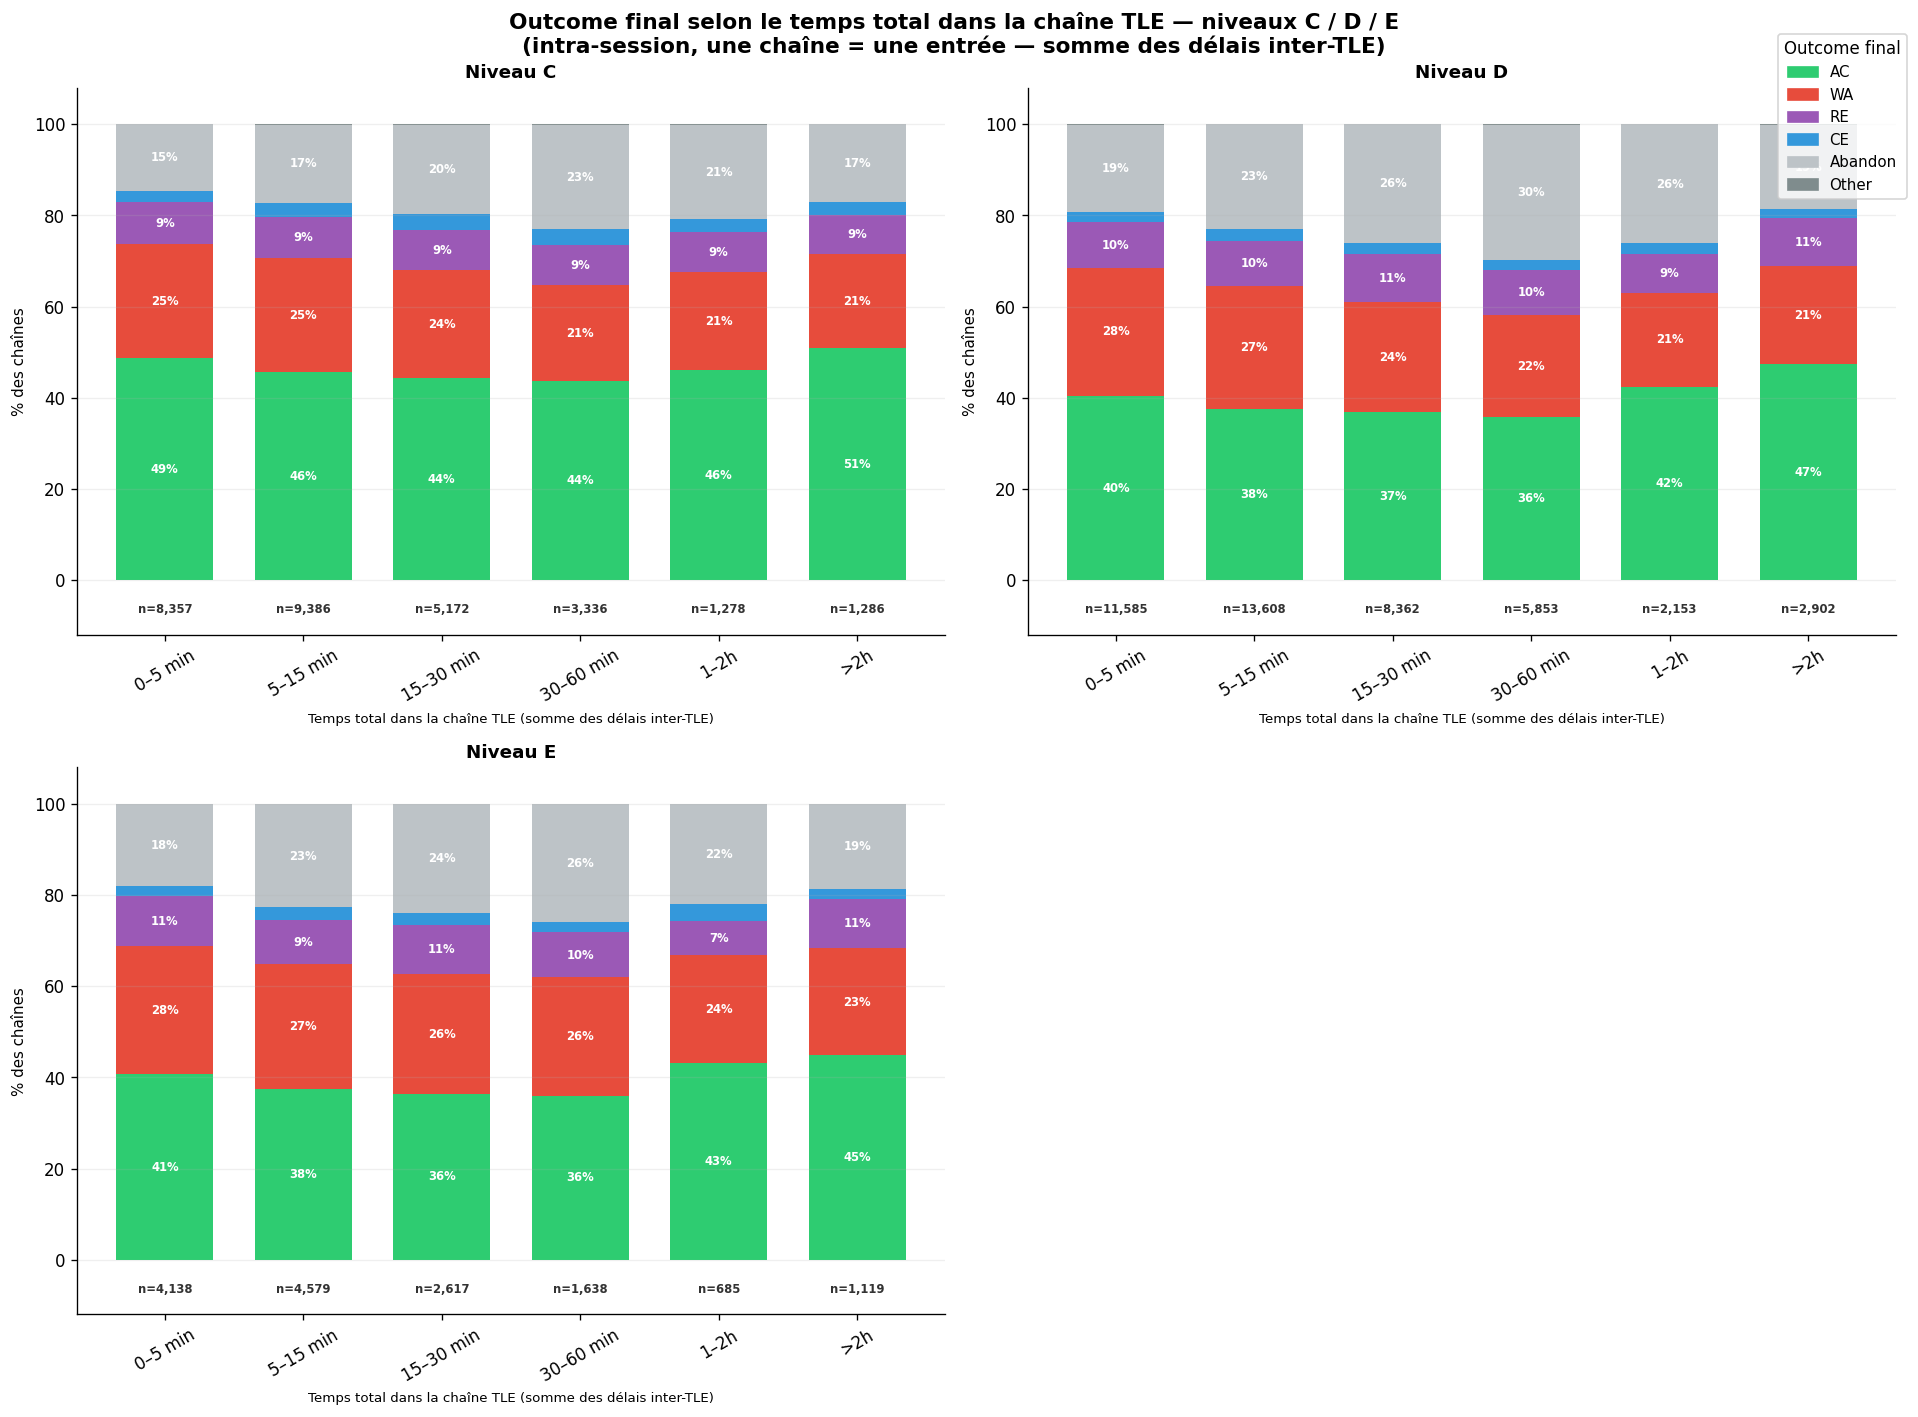

In [8]:
assert 'chain_total_time' in df_chains.columns, \
    "chain_total_time manquant — relancer `python src/main.py` puis recharger le notebook"

S6_EDGES  = [0, 300, 900, 1800, 3600, 7200, float('inf')]
S6_LABELS = ['0–5 min', '5–15 min', '15–30 min', '30–60 min', '1–2h', '>2h']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, diff in zip(axes, ['C', 'D', 'E']):
    sub = df_unique.filter(pl.col('difficulty') == diff)

    bin_counts = {}
    bin_totals = {}
    for j, label in enumerate(S6_LABELS):
        lo, hi = S6_EDGES[j], S6_EDGES[j + 1]
        grp = sub.filter((pl.col('chain_total_time') >= lo) & (pl.col('chain_total_time') < hi))
        n = grp.height
        bin_totals[label] = max(n, 1)
        bin_counts[label] = {s: grp.filter(pl.col('chain_final_outcome') == s).height
                              for s in OUTCOMES_CHAIN}

    bottoms = np.zeros(len(S6_LABELS))
    for outcome in OUTCOMES_CHAIN:
        pcts = np.array([
            100 * bin_counts[l][outcome] / bin_totals[l]
            for l in S6_LABELS
        ])
        ax.bar(S6_LABELS, pcts, bottom=bottoms,
               color=STATUS_COLORS.get(outcome, '#888'), label=outcome, width=0.7)
        for i, (pct, bot) in enumerate(zip(pcts, bottoms)):
            if pct > 5:
                ax.text(i, bot + pct / 2, f'{pct:.0f}%',
                        ha='center', va='center', fontsize=7,
                        fontweight='bold', color='white')
        bottoms += pcts

    for i, label in enumerate(S6_LABELS):
        n = bin_totals[label]
        clr = '#c0392b' if n < 150 else '#333'
        ax.text(i, -5, f'n={n:,}', ha='center', va='top', fontsize=7,
                fontweight='bold', color=clr)

    ax.set_ylim(-12, 108)
    ax.set_title(f'Niveau {diff}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Temps total dans la chaîne TLE (somme des délais inter-TLE)', fontsize=8)
    ax.set_ylabel('% des chaînes', fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.2)

axes[3].set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS.get(s, '#888'), label=s) for s in OUTCOMES_CHAIN]
fig.legend(handles=handles, title='Outcome final', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Outcome final selon le temps total dans la chaîne TLE — niveaux C / D / E\n'
    '(intra-session, une chaîne = une entrée — somme des délais inter-TLE)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Section 7 — Outcome final selon le délai inter-TLE moyen de la chaîne
## Final Outcome by Mean Inter-TLE Delay per Chain

**Correction du biais de S1 :** en S1, chaque transition TLE→TLE est un point distinct, mais toutes les transitions d'une même chaîne partagent le même `chain_final_outcome`. Une chaîne de longueur 4 contribue 3 points avec le même outcome — le double-comptage biaise les distributions.

**Ici : une chaîne = un point.** On calcule le délai inter-TLE moyen de la chaîne (`chain_total_time / (chain_length - 1)`) et on regarde l'outcome final. Le signal capté est "les utilisateurs qui prennent en moyenne plus de temps entre leurs TLEs sortent-ils mieux de la chaîne ?"

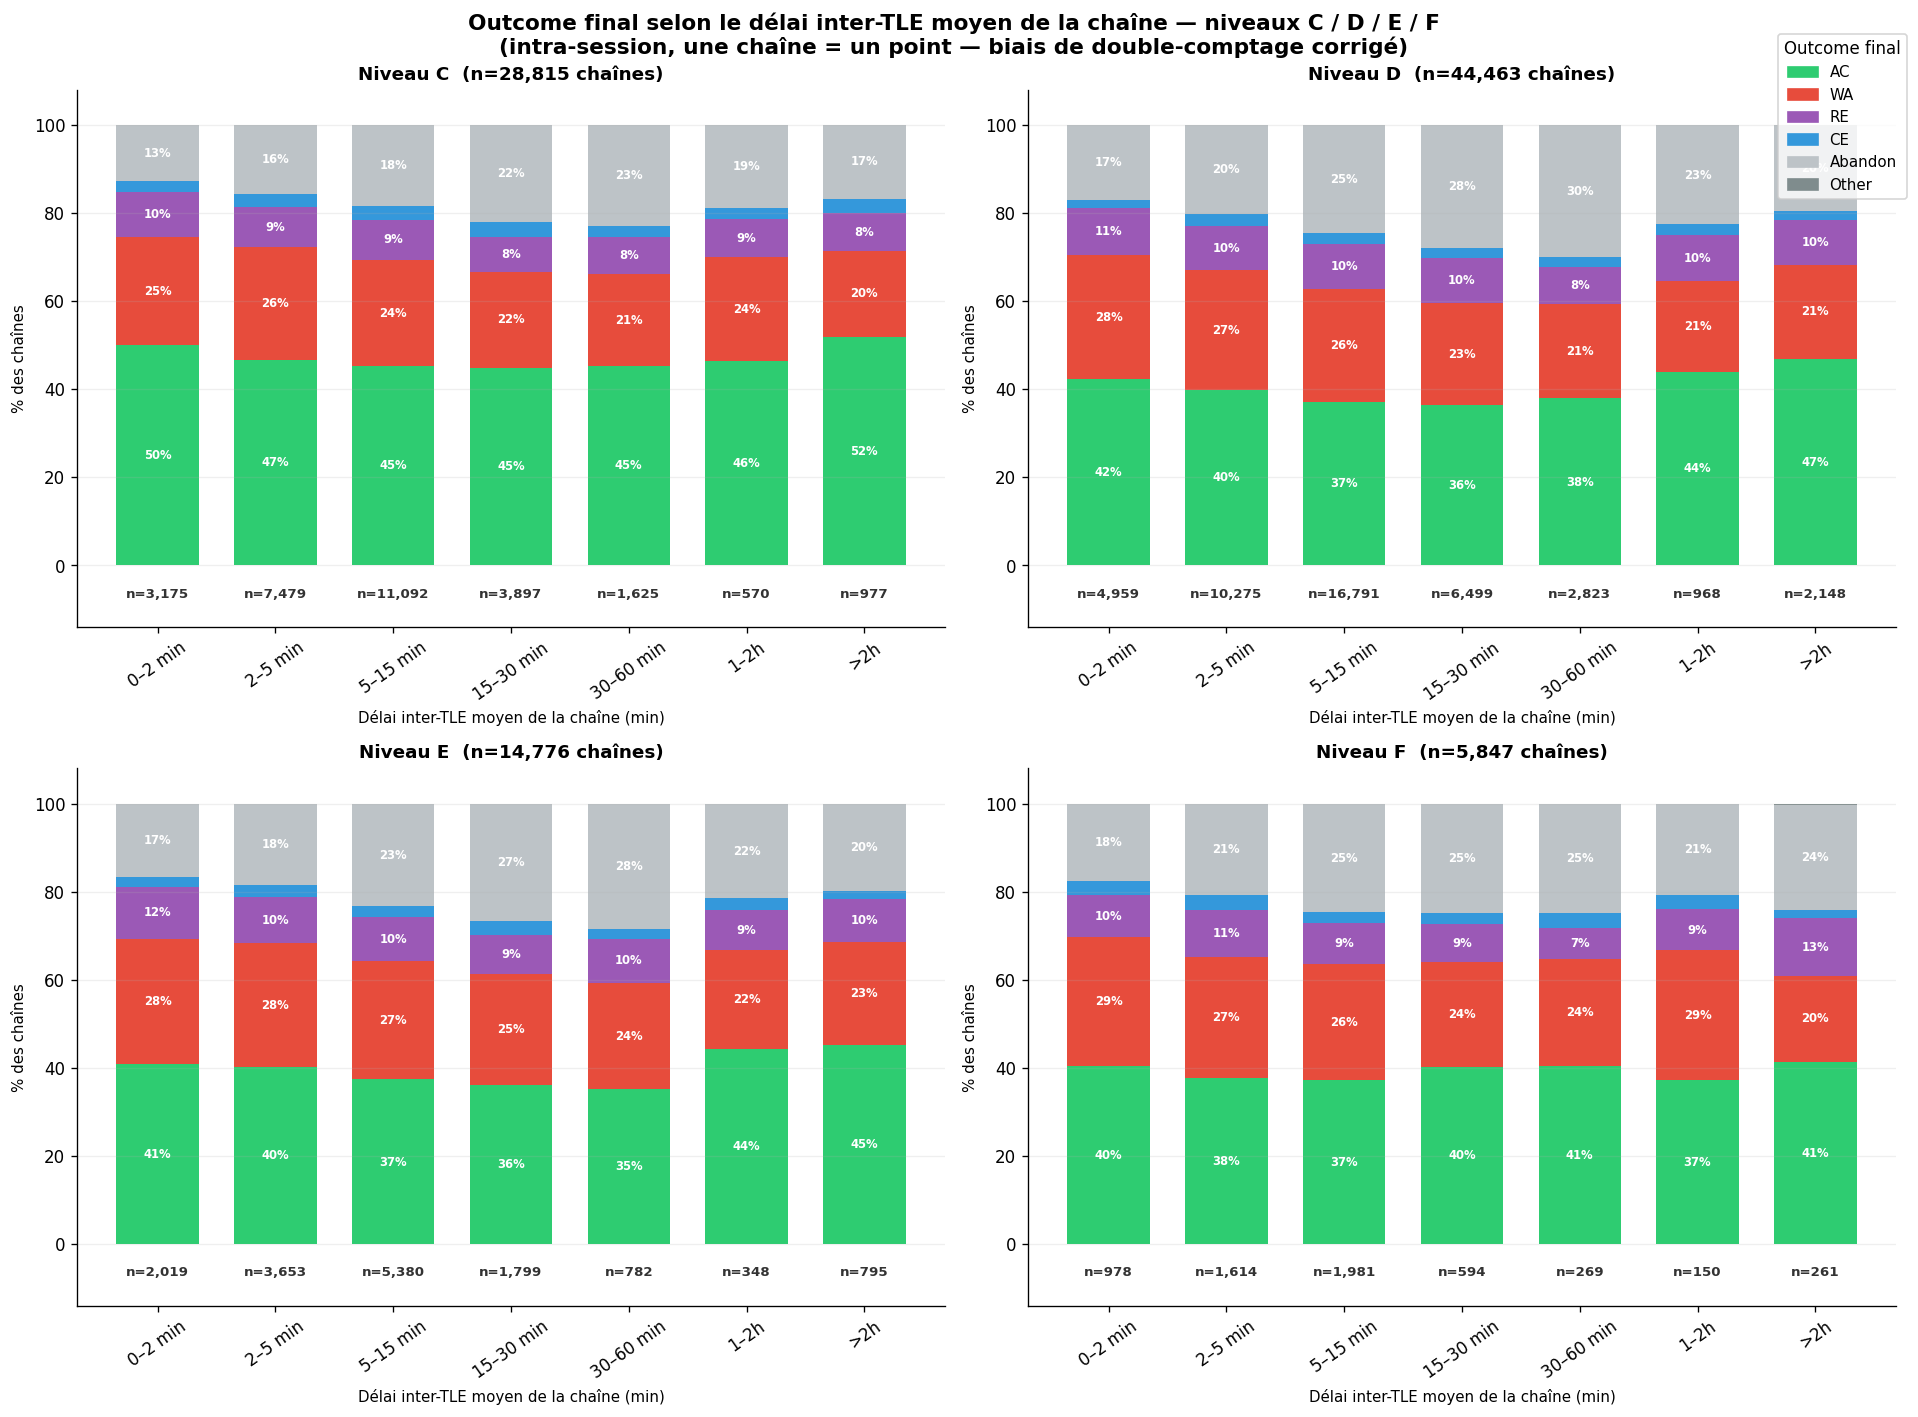

In [9]:
assert 'chain_total_time' in df_chains.columns, \
    "chain_total_time manquant — relancer `python src/main.py` puis recharger le notebook"

# Délai moyen par chaîne (en minutes) = chain_total_time / (chain_length - 1)
df_s7 = df_unique.with_columns(
    (pl.col('chain_total_time') / (pl.col('chain_length') - 1) / 60).alias('avg_delay_min')
)

S7_EDGES  = [0, 2, 5, 15, 30, 60, 120, float('inf')]
S7_LABELS = ['0–2 min', '2–5 min', '5–15 min', '15–30 min', '30–60 min', '1–2h', '>2h']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, diff in zip(axes, ['C', 'D', 'E', 'F']):
    sub = df_s7.filter(pl.col('difficulty') == diff)

    bin_counts = {}
    bin_totals = {}
    for j, label in enumerate(S7_LABELS):
        lo, hi = S7_EDGES[j], S7_EDGES[j + 1]
        grp = sub.filter((pl.col('avg_delay_min') >= lo) & (pl.col('avg_delay_min') < hi))
        n = grp.height
        bin_totals[label] = max(n, 1)
        bin_counts[label] = {s: grp.filter(pl.col('chain_final_outcome') == s).height
                              for s in OUTCOMES_CHAIN}

    bottoms = np.zeros(len(S7_LABELS))
    for outcome in OUTCOMES_CHAIN:
        pcts = np.array([
            100 * bin_counts[l][outcome] / bin_totals[l]
            for l in S7_LABELS
        ])
        ax.bar(S7_LABELS, pcts, bottom=bottoms,
               color=STATUS_COLORS.get(outcome, '#888'), label=outcome, width=0.7)
        for i, (pct, bot) in enumerate(zip(pcts, bottoms)):
            if pct > 5:
                ax.text(i, bot + pct / 2, f'{pct:.0f}%',
                        ha='center', va='center', fontsize=7,
                        fontweight='bold', color='white')
        bottoms += pcts

    for i, label in enumerate(S7_LABELS):
        n = bin_totals[label]
        clr = '#c0392b' if n < 150 else '#333'
        ax.text(i, -5, f'n={n:,}', ha='center', va='top', fontsize=8,
                fontweight='bold', color=clr)

    ax.set_ylim(-14, 108)
    ax.set_title(f'Niveau {diff}  (n={sub.height:,} chaînes)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Délai inter-TLE moyen de la chaîne (min)', fontsize=9)
    ax.set_ylabel('% des chaînes', fontsize=9)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.2)

handles = [mpatches.Patch(color=STATUS_COLORS.get(s, '#888'), label=s) for s in OUTCOMES_CHAIN]
fig.legend(handles=handles, title='Outcome final', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Outcome final selon le délai inter-TLE moyen de la chaîne — niveaux C / D / E / F\n'
    '(intra-session, une chaîne = un point — biais de double-comptage corrigé)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()